# Construire un Agent IA de Type Enfant en Python
### Atelier pour création from scratch d'une IA en passant par tous les maths importants

---

**Ce que couvre ce notebook :**
- Vectorisation TF-IDF (couche de perception)
- Similarite cosinus (couche de decision)
- Mises a jour bayesiennes de la force de croyance (couche d'apprentissage)
- Un classifieur Naive Bayes incremental (le vrai modele dans l'identite)
- Une boucle complete `perceive -> decide -> evaluate -> update`
- Demo en direct avec des exemples de triage medical

**Ce que ce n'est PAS :**
- De l'apprentissage par renforcement (pas de signal de recompense, pas de politique, pas de fonction de valeur)
- Un simple wrapper de modele pre-entraine (nous construisons chaque composant)
- Une architecture basee sur une base memoire (l'apprentissage vit *dans* l'identite, pas a l'exterieur)

**Préréquis pour mener à bien cette construction :**
- Python beginner
- Statistiques
- Une logique de programmation

# Requirements
Packages and modules to install

In [ ]:
!pip install matplotlib numpy scikit-learn scipy

## 0. Imports

In [1]:
from __future__ import annotations

import math
import json
from copy import deepcopy
from dataclasses import dataclass, field
from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple
from pprint import pformat

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist


LINE = "=" * 78
DIVIDER = "-" * 78

print("Imports OK")


Imports OK


## 1. Mathématiques de la Perception: TF-IDF

Avant que l'agent puisse apprendre, il doit convertir le texte brut en vecteur exploitable.
Nous utilisons **TF-IDF** (Term Frequency-Inverse Document Frequency).

Le **TF-IDF** est une technique utilisée pour mesurer l'importance d'un mot dans un document par rapport à une collection de documents (appelée corpus). 

C’est le produit de deux mesures :
- **TF (Term Frequency - Fréquence du terme)** : C'est la fréquence à laquelle un mot apparaît dans un document précis. Plus un mot revient souvent, plus il semble important pour ce texte.
- **IDF (Inverse Document Frequency - Fréquence inverse en document)** : Cette mesure sert à réduire le poids des mots très courants (comme "le", "de", "est") qui apparaissent partout. Si un mot apparaît dans presque tous les documents de votre collection, son score IDF sera bas. S'il est rare et n'apparaît que dans quelques textes, son score sera élevé. 


### Formule

$$\text{TF}(t, d) = \frac{f_{t,d}}{\sum_{t'} f_{t',d}}$$

$$\text{IDF}(t) = \log\left(\frac{N + 1}{df_t + 1}\right) + 1$$

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Ou:
- $f_{t,d}$ = nombre d'occurrences du terme $t$ dans le document $d$
- $N$ = nombre total de documents vus jusque-la
- $df_t$ = nombre de documents contenant le terme $t$

**Pourquoi c'est important :** Les mots rares et specifiques (ex. "tachycardia") recoivent un poids eleve. Les mots frequents (ex. "est", "un") recoivent un poids faible. L'agent apprend *ce qui compte*, pas seulement *ce qui apparait*.

Le resultat est un **vecteur creux** dans $\mathbb{R}^V$ ou $V$ est la taille du vocabulaire.


In [3]:
# ── Demo en direct: observer TF-IDF transformer deux phrases ──────────────────────────

demo_corpus = [
    "le patient a de la fièvre et tousse",
    "le patient a une douleur thoracique",
    "la fièvre est courante dans le paludisme",
]

tfidf_demo = TfidfVectorizer(norm="l2", token_pattern=r"(?u)\b\w+\b")
matrix = tfidf_demo.fit_transform(demo_corpus).toarray()

vocab = tfidf_demo.get_feature_names_out()
print("Vocabulaire:", list(vocab))
print()
for i, sentence in enumerate(demo_corpus):
    print(f"Document {i}: '{sentence}'")
    nonzero = [(vocab[j], round(matrix[i, j], 4)) for j in matrix[i].nonzero()[0]]
    print(f"  Poids TF-IDF: {nonzero}")
    print()


Vocabulaire: ['a', 'courante', 'dans', 'de', 'douleur', 'est', 'et', 'fièvre', 'la', 'le', 'paludisme', 'patient', 'thoracique', 'tousse', 'une']

Document 0: 'le patient a de la fièvre et tousse'
  Poids TF-IDF: [('a', np.float64(0.3196)), ('de', np.float64(0.4202)), ('et', np.float64(0.4202)), ('fièvre', np.float64(0.3196)), ('la', np.float64(0.3196)), ('le', np.float64(0.2482)), ('patient', np.float64(0.3196)), ('tousse', np.float64(0.4202))]

Document 1: 'le patient a une douleur thoracique'
  Poids TF-IDF: [('a', np.float64(0.3583)), ('douleur', np.float64(0.4711)), ('le', np.float64(0.2782)), ('patient', np.float64(0.3583)), ('thoracique', np.float64(0.4711)), ('une', np.float64(0.4711))]

Document 2: 'la fièvre est courante dans le paludisme'
  Poids TF-IDF: [('courante', np.float64(0.4262)), ('dans', np.float64(0.4262)), ('est', np.float64(0.4262)), ('fièvre', np.float64(0.3241)), ('la', np.float64(0.3241)), ('le', np.float64(0.2517)), ('paludisme', np.float64(0.4262))]



## 2. Mathematiques de la Decision: Similarité Cosinus

Une fois les vecteurs obtenus, l'agent mesure a quel point une nouvelle entrée ressemble a ce qu'il connait deja.

### Formule

$$\cos(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}$$

Ou:
- $\mathbf{u}$ est le vecteur de la nouvelle entree
- $\mathbf{v}$ est le **centroide** des vecteurs d'une categorie connue
- Le resultat est dans $[0, 1]$ quand les vecteurs sont non negatifs (les poids TF-IDF sont toujours >= 0)

**Centroide de la categorie $C$ :**

$$\bar{\mathbf{v}}_C = \frac{1}{|C|} \sum_{e \in C} \mathbf{v}_e$$

**Pourquoi pas la distance euclidienne ?**  
La similarite cosinus est invariante à la longueur: peu importe si un document est plus long. C'est crucial pour de courtes notes cliniques de tailles variables.

In [12]:
# ── Demo en direct: similarite cosinus entre deux phrases ─────────────────────────

phrases = [
    "le patient a une forte fièvre",
    "l'enfant présente une température élevée",
    "panne de moteur de camion",
    "depuis ce matin j'ai une fièvre et une forte toux",
    "yaga weee",
]

tfidf_demo = TfidfVectorizer(norm="l2", token_pattern=r"(?u)\b\w+\b")

vecs = tfidf_cos.fit_transform(phrases).toarray()

query = vecs[0].reshape(1, -1)
for i, phrase in enumerate(phrases):
    sim = cosine_similarity(query, vecs[i].reshape(1, -1))[0][0]
    print(f"cos('{phrases[0]}', '{phrase}') = {sim:.4f}")


cos('le patient a une forte fièvre', 'le patient a une forte fièvre') = 1.0000
cos('le patient a une forte fièvre', 'l'enfant présente une température élevée') = 0.1098
cos('le patient a une forte fièvre', 'panne de moteur de camion') = 0.0000
cos('le patient a une forte fièvre', 'depuis ce matin j'ai une fièvre et une forte toux') = 0.3765
cos('le patient a une forte fièvre', 'yaga weee') = 0.0000


## 3. Mathématiques de l'Apprentissage: Mises à Jour Bayesiennes des Croyances

L'agent ne se contente pas de compter les occurrences d'une categorie. Il maintient une **confiance bayesienne** pour chaque croyance.

### Modele Beta-Binomial

Chaque catégorie de croyance $C$ a un prior:

$$P(\text{correct} | C) \sim \text{Beta}(\alpha_C, \beta_C)$$

Apres chaque interaction:
- Prediction correcte ou nouvelle information utile -> $\alpha_C \leftarrow \alpha_C + 1$
- Incorrecte ou redondante -> $\beta_C \leftarrow \beta_C + 1$

**Force de croyance attendue (moyenne à posteriori) :**

$$\mathbb{E}[P_C] = \frac{\alpha_C}{\alpha_C + \beta_C}$$

**Pourquoi c'est mieux qu'un simple compteur :**
- C'est calibre: une categorie vue 1 fois avec 1 succes != categorie vue 10 fois avec 10 succes
- Le modele commence incertain (prior plat: $\alpha=1, \beta=1$) et se precise avec les preuves
- Il est inspectable et explicable


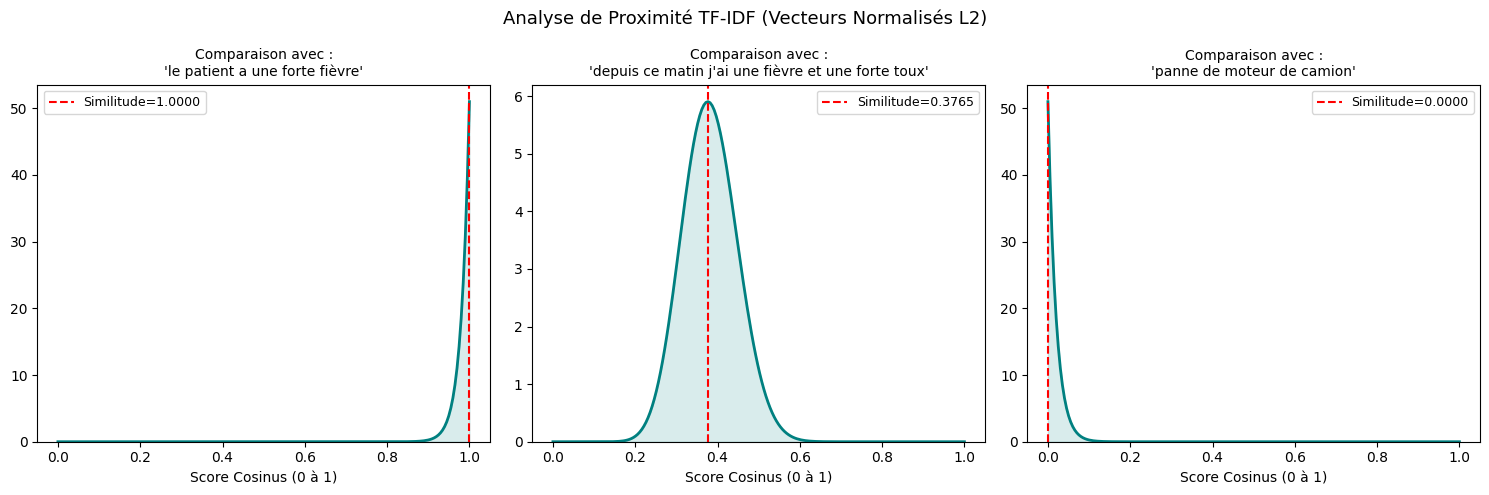

In [14]:
# 1. Calcul des similitudes
query_vec = vecs[0].reshape(1, -1)
similarities = [cosine_similarity(query_vec, vecs[i].reshape(1, -1))[0][0] for i in range(len(phrases))]

# 2. Préparation du plot (3 exemples significatifs)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# On choisit 3 indices pour illustrer : l'identique (0), le différent (2), le partiel (3)
indices_to_plot = [0, 3, 2] 

x = np.linspace(0, 1, 200)

for ax, idx in zip(axes, indices_to_plot):
    score = similarities[idx]
    phrase_comparee = phrases[idx]
    
    # On simule une distribution centrée sur le score de similitude
    # (On utilise une Beta très concentrée pour marquer le score TF-IDF)
    y = beta_dist.pdf(x, score * 50 + 1, (1 - score) * 50 + 1)

    ax.plot(x, y, lw=2, color="teal")
    ax.axvline(score, color="red", linestyle="--", label=f"Similitude={score:.4f}")
    ax.fill_between(x, y, alpha=0.15, color="teal")

    ax.set_title(f"Comparaison avec :\n'{phrase_comparee}'", fontsize=10)
    ax.set_xlabel("Score Cosinus (0 à 1)")
    ax.legend(fontsize=9)
    ax.set_ylim(0, None)

plt.suptitle("Analyse de Proximité TF-IDF (Vecteurs Normalisés L2)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Le Vrai Modèle: Naive Bayes Incremental

Dans l'identité, nous intégrons un classifieur **Complement Naive Bayes** pouvant être mis à jour incrémentalement avec `partial_fit` sans re-entrainement complet.

### Les maths

Etant donne une classe $C$ et un vecteur de caracteristiques $\mathbf{x}$, Naive Bayes predit:

$$\hat{C} = \arg\max_C \left[ \log P(C) + \sum_{i} x_i \cdot \log P(f_i | C) \right]$$

**Complement Naive Bayes** apprend à partir du *complement* de chaque classe (ce qu'une classe *n'est pas*), ce qui marche mieux sur des données textuelles creuses et deséquilibrées:

$$\hat{C} = \arg\min_C \left[ \sum_{i} x_i \cdot \log P(f_i | \bar{C}) \right]$$

**`partial_fit`** signifie que le modèle met à jour ses statistiques suffisantes (comptes de mots par classe) à partir de nouveaux exemples sans revoir les anciennes donnees. C'est ainsi que l'identité evolue depuis l'interaction.

### Pourquoi pas un reseau de neurones ?

| Proprietes | Naive Bayes (notre choix) | Reseau de neurones |
|----|---|---|
| Mise à jour incrémentale | ✅ native | ❌ re-entrainement complet |
| Exécution CPU seulement | ✅ | ❌ plus lent |
| Poids inspectables | ✅ | ❌ boîte noire |
| Données minimales de depart | 1 exemple | centaines |
| Fonctionne hors ligne | ✅ | ✅ |


---
## 5. L'Agent Complet


In [20]:
@dataclass
class Decision:
    """Une prediction simple retournée par l'agent."""
    prediction: str
    confidence: float     # score de similarité cosinus [0, 1]
    model_confidence: float  # probabilité postérieure Naive Bayes [0, 1]
    reason: str


@dataclass
class Belief:
    """Une catégorie dans le magasin d'identité, avec état bayésien complet."""
    examples: List[str] = field(default_factory=list)
    alpha: float = 1.0   # Beta-Binomial: succes + 1 (lissage de Laplace)
    beta: float = 1.0    # Beta-Binomial: echecs + 1

    @property
    def strength(self) -> float:
        """Moyenne posterior de Beta(alpha, beta), force de croyance bayesienne."""
        return self.alpha / (self.alpha + self.beta)


class ChildLikeAgent:
    """
    Un agent IA de type enfant avec un vrai modèle integré dans son identité.

    Architecture:
    - Perception  : Véctoriseur TF-IDF (incremental, s'adapte à la croissance du corpus)
    - Decision    : Similarité cosinus contre les centroides de croyances
                    + probabilité postérieure Complement Naive Bayes
    - Evaluation  : Portail d'utilité (originalité + correction + incertitude)
    - Apprentissage: Mise à jour de croyance Beta-Binomial + partial_fit sur le modèle

    Rien ici n'est de l'apprentissage par renforcement:
    - Pas de signal de recompense
    - Pas de gradient de politique
    - Pas de fonction de valeur
    - Pas de replay buffer
    """

    CONFIDENCE_THRESHOLD = 0.30  # similarite cosinus en-dessous -> "Je ne sais pas"
    MODEL_THRESHOLD = 0.50       # postérieure Bayes en-dessous -> se fier à la similarité
    MIN_EXAMPLES_FOR_MODEL = 10   # besoin d'au moins ce nombre d'exemples avant de faire confiance au modele

    def __init__(self, name: str = "Sophia") -> None:
        # ── Magasin d'identite ────────────────────────────────────────────────────
        self.identity: Dict[str, Any] = {
            "name": name,
            "version": 1,
            "beliefs": {},          # categorie → Belief
            "interaction_count": 0,
            "learning_count": 0,
            "ignored_count": 0,
            "last_update_reason": "Agent initialisé.",
        }
        # ── Couche de perception ──────────────────────────────────────────────────
        self._vectorizer = TfidfVectorizer(norm="l2", token_pattern=r"(?u)\b\w+\b", sublinear_tf=True)
        self._corpus: List[str] = []          # tous les textes vus jusque-la
        self._corpus_labels: List[str] = []   # etiquettes alignées
        self._fitted = False

        # ── Vrai mod;le (Naive Bayes) ──────────────────────────────────────────
        self._model = ComplementNB(alpha=1.0)  # alpha = lissage de Laplace
        self._label_encoder = LabelEncoder()
        self._model_ready = False

    # ──────────────────────────────────────────────────────────────────────────
    # PERCEPTION
    # ──────────────────────────────────────────────────────────────────────────
    def perceive(self, text: str) -> Dict[str, Any]:
        """
        Transformer le texte brut en vecteur TF-IDF.

        Si le corpus a ete vu avant, re-adapter le vectoriseur sur le
        corpus complet afin que les poids IDF soient toujours actuels.
        """
        normalized = text.strip().lower()
        tokens = normalized.split()

        # Adapter/Re-adapter le vectoriseur sur le corpus connu complet + nouveau texte
        fit_corpus = self._corpus + [normalized]
        self._vectorizer.fit(fit_corpus)
        self._fitted = True
        
        vec = self._vectorizer.transform([normalized]).toarray()[0]

        return {
            "raw_text": text,
            "normalized": normalized,
            "tokens": tokens,
            "vector": vec,          # np.ndarray, forme (V,)
            "vocab_size": len(self._vectorizer.vocabulary_),
        }

    # ──────────────────────────────────────────────────────────────────────────
    # DECISION
    # ──────────────────────────────────────────────────────────────────────────
    def decide(self, perception: Dict[str, Any]) -> Decision:
        """
        Etapes de decision en deux temps:
        1. Similarité cosinus contre les centroides par categorie (toujours disponible)
        2. Postérieure Naive Bayes (disponible des que MIN_EXAMPLES_FOR_MODEL est atteint)

        Confiance finale = melange ponderé des deux signaux quand le modéle est prêt.
        """
        beliefs = self.identity["beliefs"]
        input_vec = perception["vector"]

        if not beliefs:
            return Decision(
                prediction="Je ne sais pas encore.",
                confidence=0.0,
                model_confidence=0.0,
                reason="Aucune croyance dans l'identité pour le moment.",
            )

        # ── Etape 1: similarite cosinus ────────────────────────────────────────
        best_cat: Optional[str] = None
        best_cos = 0.0

        for cat, belief in beliefs.items():
            if not belief.examples:
                continue
            # Re-projeter les exemples stockes a travers le vectoriseur actuel
            example_vecs = self._vectorizer.transform(belief.examples).toarray()
            centroid = example_vecs.mean(axis=0)              # vecteur moyen
            norm = np.linalg.norm(centroid)
            if norm == 0:
                continue
            centroid_normed = centroid / norm
            cos = float(np.dot(input_vec, centroid_normed))   # similarite cosinus
            # Pondere par la force de croyance bayesienne
            weighted = cos * belief.strength
            if weighted > best_cos:
                best_cos = weighted
                best_cat = cat

        # ── Etape 2: Naive Bayes (quand pret) ────────────────────────────────
        model_conf = 0.0
        model_pred = None
        total_examples = sum(len(b.examples) for b in beliefs.values())

        if self._model_ready and total_examples >= self.MIN_EXAMPLES_FOR_MODEL:
            try:
                X = self._vectorizer.transform([perception["normalized"]])
                probs = self._model.predict_proba(X)[0]
                best_idx = int(np.argmax(probs))
                model_conf = float(probs[best_idx])
                model_pred = self._label_encoder.classes_[best_idx]
            except Exception:
                pass  # modele pas pret encore

        # ── Melanger les signaux ─────────────────────────────────────────────────
        if model_pred and model_conf >= self.MODEL_THRESHOLD:
            # Faire confiance au modele a mesure que la preuve s'accumule
            blend = 0.4 * best_cos + 0.6 * model_conf
            final_pred = model_pred
            reason = (
                f"Posterieure modele={model_conf:.3f}, "
                f"cosinus={best_cos:.3f}, melange={blend:.3f}"
            )
        else:
            blend = best_cos
            final_pred = best_cat or "Je ne sais pas."
            reason = f"Similarite cosinus (ponderee par force de croyance) = {best_cos:.3f}"

        if blend < self.CONFIDENCE_THRESHOLD or best_cat is None:
            return Decision(
                prediction="Je ne sais pas.",
                confidence=round(blend, 4),
                model_confidence=round(model_conf, 4),
                reason=reason + " — en-dessous du seuil.",
            )

        return Decision(
            prediction=final_pred,
            confidence=round(blend, 4),
            model_confidence=round(model_conf, 4),
            reason=reason,
        )

    # ──────────────────────────────────────────────────────────────────────────
    # EVALUER UTILITE
    # ──────────────────────────────────────────────────────────────────────────
    def evaluate_usefulness(
        self,
        perception: Dict[str, Any],
        decision: Decision,
        feedback_label: str,
    ) -> Dict[str, Any]:
        """
        L'agent decide si ce retour doit mettre a jour son identité.

        Regles (PAS des signaux de recompense):
        - Nouvelle categorie → utile (originalite)
        - Nouvel exemple  → utile (couverture)
        - Incertain (confiance < seuil) → utile
        - En erreur    → utile (correction)
        - Sinon    → redondant, sauter
        """
        beliefs = self.identity["beliefs"]
        known = beliefs.get(feedback_label)

        is_new_category = known is None
        is_new_example = not known or perception["normalized"] not in known.examples
        was_uncertain = decision.confidence < self.CONFIDENCE_THRESHOLD
        was_wrong = (
            decision.prediction not in {feedback_label, "Je ne sais pas.", "Je ne sais pas encore."}
        )

        useful = is_new_category or is_new_example or was_uncertain or was_wrong

        reasons = []
        if is_new_category: reasons.append("nouvelle categorie")
        if is_new_example:  reasons.append("nouvel exemple")
        if was_uncertain:   reasons.append("agent incertain")
        if was_wrong:       reasons.append("agent en erreur")
        if not reasons:     reasons.append("redondant")

        return {"useful": useful, "reason": ", ".join(reasons)}

    # ──────────────────────────────────────────────────────────────────────────
    # APPRENDRE (mise à jour d'identité)
    # ──────────────────────────────────────────────────────────────────────────
    def learn(
        self,
        perception: Dict[str, Any],
        decision: Decision,
        feedback_label: str,
        usefulness: Dict[str, Any],
    ) -> bool:
        """
        Mettre à jour l'identité quand le retour est jugé utile:

        1. Ajouter exemple au magasin de croyance
        2. Mise a jour de croyance bayesienne: alpha += 1 si correct/nouveau, beta += 1 si faux
        3. partial_fit du modele Naive Bayes sur le nouvel exemple
        4. Incrementer le compteur de version
        """
        self.identity["interaction_count"] += 1

        if not usefulness["useful"]:
            self.identity["ignored_count"] += 1
            self.identity["last_update_reason"] = f"Saute: {usefulness['reason']}."
            # Penalite bayesienne: beta += 1 pour la categorie predite (si presente)
            if decision.prediction in self.identity["beliefs"]:
                self.identity["beliefs"][decision.prediction].beta += 1
            return False

        beliefs = self.identity["beliefs"]
        text = perception["normalized"]

        # ── 1. Mettre a jour le magasin de croyance ─────────────────────────
        if feedback_label not in beliefs:
            beliefs[feedback_label] = Belief()
        belief = beliefs[feedback_label]

        if text not in belief.examples:
            belief.examples.append(text)

        # ── 2. Mise a jour bayesienne ─────────────────────────────────────────
        was_correct = decision.prediction == feedback_label
        if was_correct:
            belief.alpha += 1.0   # renforcement: categorie correcte confirmée
        else:
            belief.alpha += 0.5   # apprendre quelque chose de nouveau, credit partiel
            belief.beta += 0.5    # une incertitude acknowledger

        # ── 3. Mettre à jour corpus et partial_fit le modele ─────────────────
        self._corpus.append(text)
        self._corpus_labels.append(feedback_label)

        all_classes = list(set(self._corpus_labels))
        if len(all_classes) >= 2:
            # Re-adapter le vectoriseur sur le corpus complet (mise a jour IDF) puis re-entrainer
            # le modele a partir du corpus entier afin que les dimensions de caracteristiques
            # soient toujours coherentes apres la croissance du vocabulaire.
            self._vectorizer.fit(self._corpus)
            X_all = self._vectorizer.transform(self._corpus)
            self._label_encoder.fit(all_classes)
            y_all = self._label_encoder.transform(self._corpus_labels)
            self._model = ComplementNB(alpha=1.0)
            self._model.partial_fit(
                X_all, y_all,
                classes=self._label_encoder.transform(all_classes)
            )
            self._model_ready = True

        # ── 4. Mettre a jour les metadata d'identite ────────────────────────────
        self.identity["learning_count"] += 1
        self.identity["version"] += 1
        self.identity["last_update_reason"] = (
            f"Appris '{feedback_label}': {usefulness['reason']}. "
            f"Force de croyance={belief.strength:.3f} "
            f"(α={belief.alpha:.1f}, β={belief.beta:.1f})."
        )
        return True

print("Classe Agent définie.")


Classe Agent définie.


## 6. Ensemble de Donnees Sante

Scenario du monde reel: une clinique avec peu de ressources utilise l'agent pour aider au triage des plaintes des patients quand il n'y a pas d'internet et pas de GPU disponible.


In [21]:
HEALTHCARE_INTERACTIONS = [
    # ── Respiratoire ──────────────────────────────────────────────────────────
    {"input": "le patient a une toux persistente et un essoufflement",    "label": "respiratoire"},
    {"input": "l'enfant a une respiration sifflante et laborieuse",              "label": "respiratoire"},
    {"input": "l'adulte rapporte une oppression thoracique et une respiration rapide",       "label": "respiratoire"},
    {"input": "patient âgé avec une toux chronique et une production de mucus", "label": "respiratoire"},
    # ── Fievre / Infection ─────────────────────────────────────────────────────
    {"input": "le patient se présente avec une forte fièvre et des frissons",            "label": "fievre_infection"},
    {"input": "l'enfant a une température de 39 degrés et des douleurs corporelles",         "label": "fievre_infection"},
    {"input": "l'adulte rapporte une transpiration et une température élevée",        "label": "fievre_infection"},
    {"input": "le patient montre des signes de paludisme, fièvre élevée et fatigue",  "label": "fievre_infection"},
    # ── Cardiaque ───────────────────────────────────────────────────────────────
    {"input": "le patient a une douleur thoracique irradiant vers le bras gauche",       "label": "cardiaque"},
    {"input": "l'adulte rapporte des palpitations et un rythme cardiaque irrégulier",     "label": "cardiaque"},
    {"input": "le patient âgé présente une tachycardie et des vertiges à l'effort",    "label": "cardiaque"},
    # ── Gastro-intestinal ──────────────────────────────────────────────────────
    {"input": "le patient rapporte une douleur abdominale sévère et des vomissements",     "label": "gastro-intestinal"},
    {"input": "l'enfant a la diarrhée et des crampes d'estomac depuis hier",  "label": "gastro-intestinal"},
    {"input": "l'adulte se présente avec des nausées et une perte d'appétit",        "label": "gastro-intestinal"},
    # ── Neurologique ──────────────────────────────────────────────────────────
    {"input": "le patient a un mal de tête sévère et une sensibilité à la lumière",      "label": "neurologique"},
    {"input": "l'enfant montre une confusion et une activité convulsive",             "label": "neurologique"},
    {"input": "l'adulte rapporte un engourdissement de la main gauche et une parole difficile", "label": "neurologique"},
    # ── Requetes de test non-vues (pas dans l'entrainement) ─────────────────────────────────
    {"input": "le patient respire difficilement après avoir couru",         "label": "respiratoire"},
    {"input": "l'enfant a un rythme cardiaque très rapide pendant le sommeil",          "label": "cardiaque"},
    {"input": "le patient a une température élevée et une douleur articulaire",            "label": "fievre_infection"},
]

print(f"{len(HEALTHCARE_INTERACTIONS)} interactions prets.")


20 interactions prets.


## 7. Executer la Boucle d'Apprentissage Complete


In [22]:
def run_agent(interactions: List[Dict[str, str]], verbose: bool = True) -> ChildLikeAgent:
    """Executer l'agent sur une serie d'interactions."""
    agent = ChildLikeAgent(name="Sophia")

    print(LINE)
    print("AGENT IA DE TYPE ENFANT — DEMO TRIAGE MEDICAL")
    print("Architecture: TF-IDF + Similarite Cosinus + Complement Naive Bayes")
    print("Apprentissage:     Mises a jour Beta-Binomial Bayesiennes + partial_fit")
    print(LINE)

    results = []

    for i, item in enumerate(interactions, 1):
        before = deepcopy(agent.identity)

        perception  = agent.perceive(item["input"])
        decision    = agent.decide(perception)
        usefulness  = agent.evaluate_usefulness(perception, decision, item["label"])
        learned     = agent.learn(perception, decision, item["label"], usefulness)

        correct = decision.prediction == item["label"]
        results.append(correct)

        if verbose:
            print(DIVIDER)
            print(f"[{i:02d}] ENTREE     : {item['input']}")
            print(f"     PREDICTION: {decision.prediction}")
            print(f"     ETIQUETTE : {item['label']}")
            print(f"     CONFIANCE : cosinus={decision.confidence:.4f}  modele={decision.model_confidence:.4f}")
            print(f"     CORRECT ?  : {'✓' if correct else '✗'}")
            print(f"     UTILE ?    : {usefulness['useful']}  ({usefulness['reason']})")
            print(f"     APPRIS ?   : {learned}")
            print(f"     MISE A JOUR: {agent.identity['last_update_reason']}")

            # Afficher les forces de croyances actuelles
            if agent.identity["beliefs"]:
                strengths = {
                    cat: f"{b.strength:.3f} (α={b.alpha:.1f},β={b.beta:.1f})"
                    for cat, b in agent.identity["beliefs"].items()
                }
                print(f"     CROYANCES  : {json.dumps(strengths, indent=18)[1:-1].strip()}")

    print(LINE)
    print("RESUME FINAL")
    print(LINE)
    print(f"Interactions   : {agent.identity['interaction_count']}")
    print(f"Appris         : {agent.identity['learning_count']}")
    print(f"Ignores        : {agent.identity['ignored_count']}")
    print(f"Ver. identite  : {agent.identity['version']}")
    accuracy = sum(results) / len(results)
    print(f"Precision      : {accuracy:.1%}  ({sum(results)}/{len(results)} corrects)")
    print("Categories     :", ", ".join(agent.identity["beliefs"].keys()))

    return agent


agent = run_agent(HEALTHCARE_INTERACTIONS, verbose=True)


AGENT IA DE TYPE ENFANT — DEMO TRIAGE MEDICAL
Architecture: TF-IDF + Similarite Cosinus + Complement Naive Bayes
Apprentissage:     Mises a jour Beta-Binomial Bayesiennes + partial_fit
------------------------------------------------------------------------------
[01] ENTREE     : le patient a une toux persistente et un essoufflement
     PREDICTION: Je ne sais pas encore.
     ETIQUETTE : respiratoire
     CONFIANCE : cosinus=0.0000  modele=0.0000
     CORRECT ?  : ✗
     UTILE ?    : True  (nouvelle categorie, nouvel exemple, agent incertain)
     APPRIS ?   : True
     MISE A JOUR: Appris 'respiratoire': nouvelle categorie, nouvel exemple, agent incertain. Force de croyance=0.500 (α=1.5, β=1.5).
     CROYANCES  : "respiratoire": "0.500 (\u03b1=1.5,\u03b2=1.5)"
------------------------------------------------------------------------------
[02] ENTREE     : l'enfant a une respiration sifflante et laborieuse
     PREDICTION: Je ne sais pas.
     ETIQUETTE : respiratoire
     CONFIANCE 

## 8. Visualiser: Croissance de la Confiance au Fil du Temps


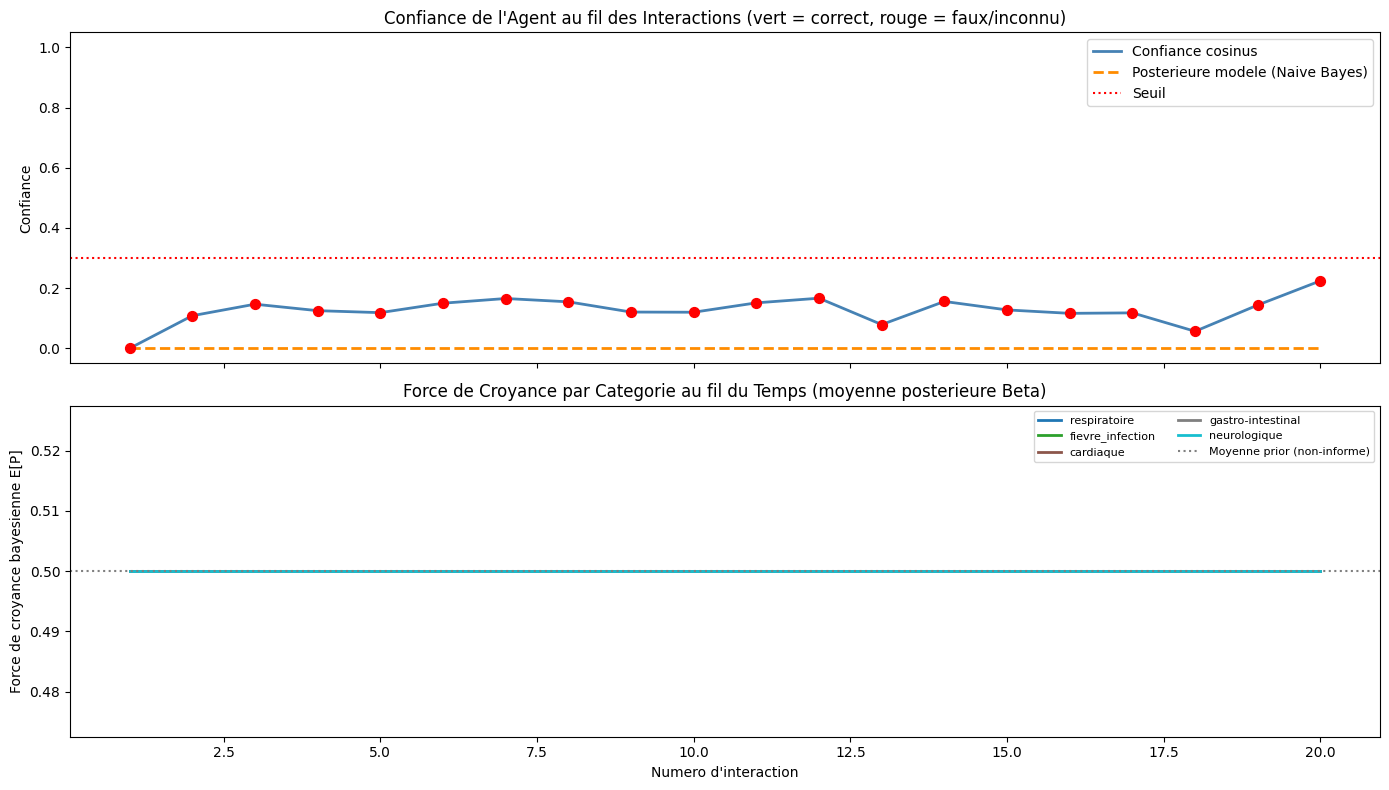

In [23]:
def plot_confidence_evolution(interactions: List[Dict[str, str]]) -> None:
    """Tracer l'évolution de la confiance et de la force de croyance au fil du temps."""
    agent = ChildLikeAgent(name="Milo-Graphique")
    confidences = []
    model_confidences = []
    correct_flags = []

    for item in interactions:
        perception = agent.perceive(item["input"])
        decision = agent.decide(perception)
        usefulness = agent.evaluate_usefulness(perception, decision, item["label"])
        agent.learn(perception, decision, item["label"], usefulness)

        confidences.append(decision.confidence)
        model_confidences.append(decision.model_confidence)
        correct_flags.append(decision.prediction == item["label"])

    x = list(range(1, len(interactions) + 1))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Confiance au fil du temps
    ax1.plot(x, confidences, label="Confiance cosinus", color="steelblue", lw=2)
    ax1.plot(x, model_confidences, label="Posterieure modele (Naive Bayes)", color="darkorange", lw=2, linestyle="--")
    ax1.axhline(ChildLikeAgent.CONFIDENCE_THRESHOLD, color="red", linestyle=":", label="Seuil")
    for i, (c, ok) in enumerate(zip(confidences, correct_flags), 1):
        color = "green" if ok else "red"
        ax1.scatter(i, c, color=color, zorder=5, s=50)
    ax1.set_ylabel("Confiance")
    ax1.set_title("Confiance de l'Agent au fil des Interactions (vert = correct, rouge = faux/inconnu)")
    ax1.legend()
    ax1.set_ylim(-0.05, 1.05)

    # Force de croyance au fil du temps (moyennes posterieures)
    agent2 = ChildLikeAgent(name="Milo-Graphique2")
    history = defaultdict(list)
    for item in interactions:
        perception = agent2.perceive(item["input"])
        decision = agent2.decide(perception)
        usefulness = agent2.evaluate_usefulness(perception, decision, item["label"])
        agent2.learn(perception, decision, item["label"], usefulness)
        for cat, b in agent2.identity["beliefs"].items():
            history[cat].append(b.strength)
        # Coussiner les categories pas encore vues
        step = max(len(v) for v in history.values())
        for cat in history:
            while len(history[cat]) < step:
                history[cat].insert(0, 0.5)  # moyenne prior

    colors = plt.cm.tab10(np.linspace(0, 1, len(history)))
    for (cat, strengths), color in zip(history.items(), colors):
        ax2.plot(range(1, len(strengths) + 1), strengths, label=cat, color=color, lw=2)

    ax2.axhline(0.5, color="gray", linestyle=":", label="Moyenne prior (non-informe)")
    ax2.set_xlabel("Numero d'interaction")
    ax2.set_ylabel("Force de croyance bayesienne E[P]")
    ax2.set_title("Force de Croyance par Categorie au fil du Temps (moyenne posterieure Beta)")
    ax2.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    
    plt.show()


plot_confidence_evolution(HEALTHCARE_INTERACTIONS)


## 9. Visualiser: Espace de Caractéristiques TF-IDF (PCA)

Voyons comment l'espace de perception de l'agent organise les exemples de santé.


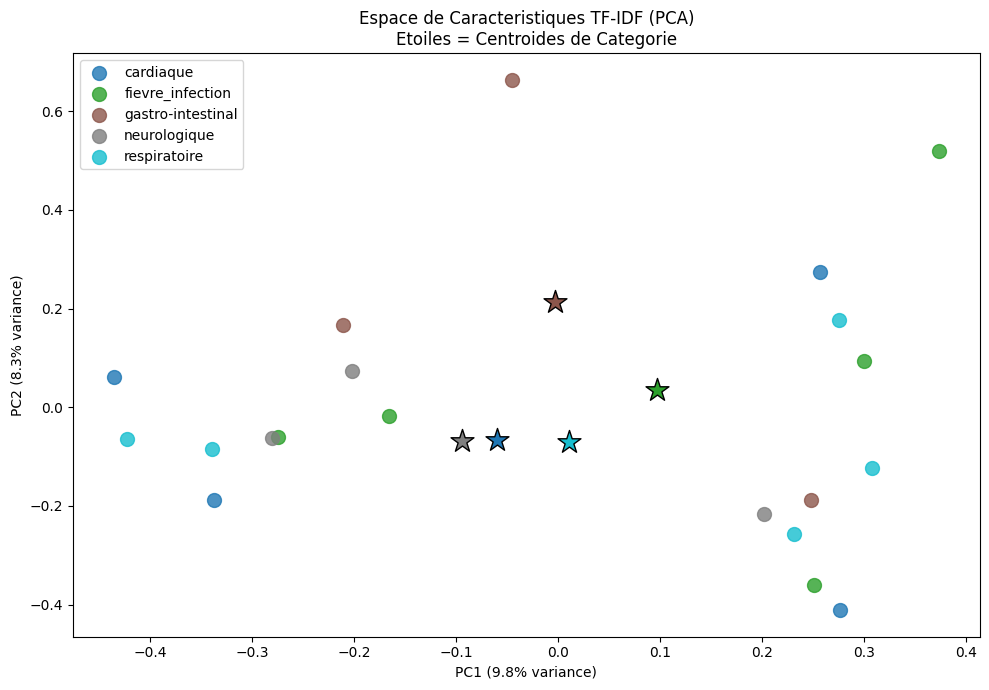

In [26]:
from sklearn.decomposition import PCA

def plot_feature_space(agent: ChildLikeAgent) -> None:
    """Tracer l'espace de caracteristiques TF-IDF avec PCA."""
    if not agent._corpus:
        print("Pas de corpus pour le moment.")
        return

    vecs = agent._vectorizer.transform(agent._corpus).toarray()
    labels = agent._corpus_labels

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vecs)

    unique_labels = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    label_color = {l: c for l, c in zip(unique_labels, colors)}

    fig, ax = plt.subplots(figsize=(10, 7))
    for label in unique_labels:
        idx = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(
            coords[idx, 0], coords[idx, 1],
            label=label, color=label_color[label], s=100, alpha=0.8
        )
        # Dessiner le centroide
        cx, cy = coords[idx, 0].mean(), coords[idx, 1].mean()
        ax.scatter(cx, cy, color=label_color[label], s=300, marker="*", edgecolors="black", zorder=5)

    variance = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({variance[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({variance[1]:.1%} variance)")
    ax.set_title("""Espace de Caracteristiques TF-IDF (PCA)
    Etoiles = Centroides de Categorie""")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_feature_space(agent)


## 10. Demo Interactive en Direct

Tapez votre propre note clinique et voyez l'agent repondre en temps reel.


In [ ]:
def live_demo(agent: ChildLikeAgent) -> None:
    """
    Boucle interactive:
    Tapez une description de symptome du patient, l'agent le classe.
    Puis tapez optionnellement la corect label pour enseigner à l'agent.
    Tapez 'quitter' pour sortir.
    """
    print(LINE)
    print("DEMO INTERACTIVE EN DIRECT")
    print("Tapez une description de symptome du patient. L'agent le classera.")
    print("Puis fournissez optionnellement la correct label pour enseigner a l'agent.")
    print(f"Categories connues: {', '.join(agent.identity['beliefs'].keys())}")
    print("Tapez 'quitter' pour sortir.")
    print(LINE)

    while True:
        text = input("\nDescription du symptome: ").strip()
        if text.lower() == "quitter":
            break
        if not text:
            continue

        perception = agent.perceive(text)
        decision = agent.decide(perception)

        print(f"  → Prediction : {decision.prediction}")
        print(f"  → Confiance : cosinus={decision.confidence:.4f}  modele={decision.model_confidence:.4f}")
        print(f"  → Raison     : {decision.reason}")

        label = input("  Etiquette correcte (Entree pour sauter): ").strip()
        if label:
            usefulness = agent.evaluate_usefulness(perception, decision, label)
            learned = agent.learn(perception, decision, label, usefulness)
            print(f"  → Utile: {usefulness['useful']} ({usefulness['reason']})")
            print(f"  → Appris: {learned}")
            if learned:
                b = agent.identity["beliefs"][label]
                print(f"  → Force de croyance: {b.strength:.3f} (α={b.alpha:.1f}, β={b.beta:.1f})")


live_demo(agent)


DEMO INTERACTIVE EN DIRECT
Tapez une description de symptome du patient. L'agent le classera.
Puis fournissez optionnellement la correct label pour enseigner a l'agent.
Categories connues: respiratoire, fievre_infection, cardiaque, gastro-intestinal, neurologique
Tapez 'quitter' pour sortir.



Description du symptome:  J'ai une toux grave


  → Prediction : Je ne sais pas.
  → Confiance : cosinus=0.0863  modele=0.0000
  → Raison     : Similarite cosinus (ponderee par force de croyance) = 0.086 — en-dessous du seuil.


  Etiquette correcte (Entree pour sauter):  J'ai une fievre extreme et forte


  → Utile: True (nouvelle categorie, nouvel exemple, agent incertain)
  → Appris: True
  → Force de croyance: 0.500 (α=1.5, β=1.5)


...

  → Utile: True (nouvel exemple, agent incertain)
  → Appris: True
  → Force de croyance: 0.500 (α=3.5, β=3.5)



Description du symptome:  j'ai des palpitations


  → Prediction : Je ne sais pas.
  → Confiance : cosinus=0.2479  modele=0.2732
  → Raison     : Similarite cosinus (ponderee par force de croyance) = 0.248 — en-dessous du seuil.


  Etiquette correcte (Entree pour sauter):  cardiaque


  → Utile: True (agent incertain)
  → Appris: True
  → Force de croyance: 0.500 (α=4.0, β=4.0)


## 11. Pourquoi Ce N'est Pas de l'Apprentissage par Renforcement - Cote a Cote

| | Apprentissage par Renforcement | Cet Agent |
|---|---|---|
| **Signal d'apprentissage** | Recompense scalaire $r_t$ | Etiquette humaine (catégorique) |
| **Objectif** | Maximiser $\sum \gamma^t r_t$ | Pas de fonction objectif |
| **Ce qui se met a jour** | Politique $\pi_\theta$ ou $Q(s,a)$ | Croyances d'identité + poids de modèle |
| **Maths** | Gradient de politique / équation Bellman | Mise à jour bayésienne + partial_fit |
| **Exploration** | $\epsilon$-greedy, ... | Incertitude → "Je ne sais pas" |
| **Re-entrainement necessaire** | Souvent | Jamais (incremental) |
| **Interpretable ?** | Rarement | Toujours (inspecter dict de croyances) |

## 12. Points de Controle de l'Atelier

Apres avoir éxecuté ce notebook, vous devriez pouvoir répondre à:

1. **Que calcule reellement TF-IDF ?** Parcourez la formule avec un exemple académique.
2. **Pourquoi la similarite cosinus, et pas la distance euclidienne ?** Quelle propriété la rend meilleure pour le texte de longueur variable ?
3. **Que fait `partial_fit` differemment de `fit` ?** Pourquoi cela importe-t-il pour un agent auto-évolutif ?
5. **Pourquoi l'agent dit-il "Je ne sais pas" ?** Quel seuil controle ceci, et comment est-il calibré ?
6. **Pourriez-vous remplacer le modele Naive Bayes par un estimateur sklearn différent ?** Quelle éxigence d'interface devrait-il satisfaire ?
